# Tax Calculator - Example Analysis

This notebook demonstrates how to use the `taxcalc` package to perform comprehensive tax calculations for Federal and California taxes.

## Setup

First, import the necessary classes from the taxcalc package:

Obtaining file:///home/azhar/tax-calculator/examples
ERROR: file:///home/azhar/tax-calculator/examples does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import the tax calculator components
from taxcalc import (
    FilingStatus,
    TaxpayerInfo,
    IncomeData,
    ItemizedDeductions,
    AMTAdjustments,
    TaxCalculator2024
)

## Example 1: High-Income Married Filing Jointly with Capital Gains

This example shows a married couple with high W-2 income, capital gains, and itemized deductions including charitable contributions to a Donor-Advised Fund.

In [2]:
# Define taxpayer information
taxpayer = TaxpayerInfo(
    filing_status=FilingStatus.MARRIED_JOINT,
    age_primary=45,
    age_spouse=43,
    num_dependents=2
)

# Define income sources
income = IncomeData(
    wages_w2=400000,
    interest_income=5000,
    qualified_dividends=15000,
    ordinary_dividends=3000,
    short_term_capital_gains=25000,
    long_term_capital_gains=100000,
    rental_income=20000
)

# Define itemized deductions
itemized = ItemizedDeductions(
    medical_dental_expenses=15000,
    state_local_income_taxes=25000,  # Subject to $10,000 SALT cap
    real_estate_taxes=18000,         # Subject to $10,000 SALT cap
    personal_property_taxes=2000,    # Subject to $10,000 SALT cap
    mortgage_interest=35000,
    cash_contributions_50pct_orgs=40000,
    donor_advised_fund_contributions=20000  # DAF contribution
)

# Create calculator and calculate taxes
calculator = TaxCalculator2024(taxpayer, income, itemized)
results = calculator.calculate_all_taxes()

# Print detailed report
print(calculator.generate_summary_report(results))


TAX CALCULATION SUMMARY - TAX YEAR 2024

TAXPAYER INFORMATION:
  Filing Status: Married Joint
  Age: 45 (Primary)
  Dependents: 2

INCOME SUMMARY

  Wages (W-2):                               $     400,000.00
  Interest Income:                           $       5,000.00
  Dividends (Qualified):                     $      15,000.00
  Dividends (Ordinary):                      $       3,000.00
  Short-Term Capital Gains:                  $      25,000.00
  Long-Term Capital Gains:                   $     100,000.00
  Self-Employment Income:                    $           0.00
  Rental Income:                             $      20,000.00
  Other Income:                              $           0.00
                                             ------------------------------
  TOTAL GROSS INCOME:                        $     568,000.00

  Adjusted Gross Income (AGI):               $     568,000.00

DEDUCTIONS

  Standard Deduction:                        $      29,200.00
  Itemized Deducti

## Example 2: Single Filer with ISO Exercise (AMT Scenario)

This example demonstrates a scenario where Alternative Minimum Tax (AMT) applies due to Incentive Stock Option (ISO) exercise and high state taxes.

In [3]:
# Define taxpayer information
taxpayer_amt = TaxpayerInfo(
    filing_status=FilingStatus.SINGLE,
    age_primary=35
)

# Define income sources
income_amt = IncomeData(
    wages_w2=250000,
    long_term_capital_gains=50000,
    qualified_dividends=10000
)

# Define itemized deductions (high SALT triggers AMT)
itemized_amt = ItemizedDeductions(
    state_local_income_taxes=30000,
    real_estate_taxes=15000,
    mortgage_interest=20000,
    cash_contributions_50pct_orgs=25000
)

# Define AMT adjustments (ISO exercise)
amt_adj = AMTAdjustments(
    iso_bargain_element=200000  # Fair market value minus exercise price
)

# Create calculator and calculate taxes
calculator_amt = TaxCalculator2024(taxpayer_amt, income_amt, itemized_amt, amt_adj)
results_amt = calculator_amt.calculate_all_taxes()

# Print detailed report
print(calculator_amt.generate_summary_report(results_amt))


TAX CALCULATION SUMMARY - TAX YEAR 2024

TAXPAYER INFORMATION:
  Filing Status: Single
  Age: 35 (Primary)
  Dependents: 0

INCOME SUMMARY

  Wages (W-2):                               $     250,000.00
  Interest Income:                           $           0.00
  Dividends (Qualified):                     $      10,000.00
  Dividends (Ordinary):                      $           0.00
  Short-Term Capital Gains:                  $           0.00
  Long-Term Capital Gains:                   $      50,000.00
  Self-Employment Income:                    $           0.00
  Rental Income:                             $           0.00
  Other Income:                              $           0.00
                                             ------------------------------
  TOTAL GROSS INCOME:                        $     310,000.00

  Adjusted Gross Income (AGI):               $     310,000.00

DEDUCTIONS

  Standard Deduction:                        $      14,600.00
  Itemized Deductions:   

## Example 3: Analyzing Different Scenarios

You can easily compare different tax scenarios by creating multiple calculator instances:

In [4]:
import pandas as pd

# Scenario 1: Standard deduction
taxpayer_std = TaxpayerInfo(
    filing_status=FilingStatus.MARRIED_JOINT,
    age_primary=40,
    age_spouse=38
)

income_std = IncomeData(
    wages_w2=200000,
    long_term_capital_gains=30000
)

itemized_std = ItemizedDeductions()  # Empty - will use standard deduction

calc_std = TaxCalculator2024(taxpayer_std, income_std, itemized_std)
results_std = calc_std.calculate_all_taxes()

# Scenario 2: With charitable giving
itemized_charity = ItemizedDeductions(
    state_local_income_taxes=10000,
    cash_contributions_50pct_orgs=30000
)

calc_charity = TaxCalculator2024(taxpayer_std, income_std, itemized_charity)
results_charity = calc_charity.calculate_all_taxes()

# Compare scenarios
comparison = pd.DataFrame({
    'Metric': [
        'Gross Income',
        'AGI',
        'Deduction Used',
        'Taxable Income',
        'Total Federal Tax',
        'Total California Tax',
        'Total Tax',
        'Effective Tax Rate'
    ],
    'Standard Deduction': [
        f'${results_std.gross_income:,.2f}',
        f'${results_std.agi:,.2f}',
        f'${results_std.deduction_used:,.2f}',
        f'${results_std.taxable_income:,.2f}',
        f'${results_std.total_federal_tax:,.2f}',
        f'${results_std.total_california_tax:,.2f}',
        f'${results_std.total_tax_liability:,.2f}',
        f'{results_std.effective_total_rate*100:.2f}%'
    ],
    'With Charitable Giving': [
        f'${results_charity.gross_income:,.2f}',
        f'${results_charity.agi:,.2f}',
        f'${results_charity.deduction_used:,.2f}',
        f'${results_charity.taxable_income:,.2f}',
        f'${results_charity.total_federal_tax:,.2f}',
        f'${results_charity.total_california_tax:,.2f}',
        f'${results_charity.total_tax_liability:,.2f}',
        f'{results_charity.effective_total_rate*100:.2f}%'
    ]
})

print(comparison.to_string(index=False))

# Calculate tax savings from charitable giving
tax_savings = results_std.total_tax_liability - results_charity.total_tax_liability
print(f"\nTax Savings from $30,000 Charitable Contribution: ${tax_savings:,.2f}")

              Metric Standard Deduction With Charitable Giving
        Gross Income        $230,000.00            $230,000.00
                 AGI        $230,000.00            $230,000.00
      Deduction Used         $29,200.00             $40,000.00
      Taxable Income        $200,800.00            $190,000.00
   Total Federal Tax         $32,182.00             $29,806.00
Total California Tax         $15,644.28             $13,884.72
           Total Tax         $47,826.28             $43,690.72
  Effective Tax Rate             20.79%                 19.00%

Tax Savings from $30,000 Charitable Contribution: $4,135.56


## Example 4: Visualizing Tax Breakdown

Create visualizations to understand your tax breakdown:

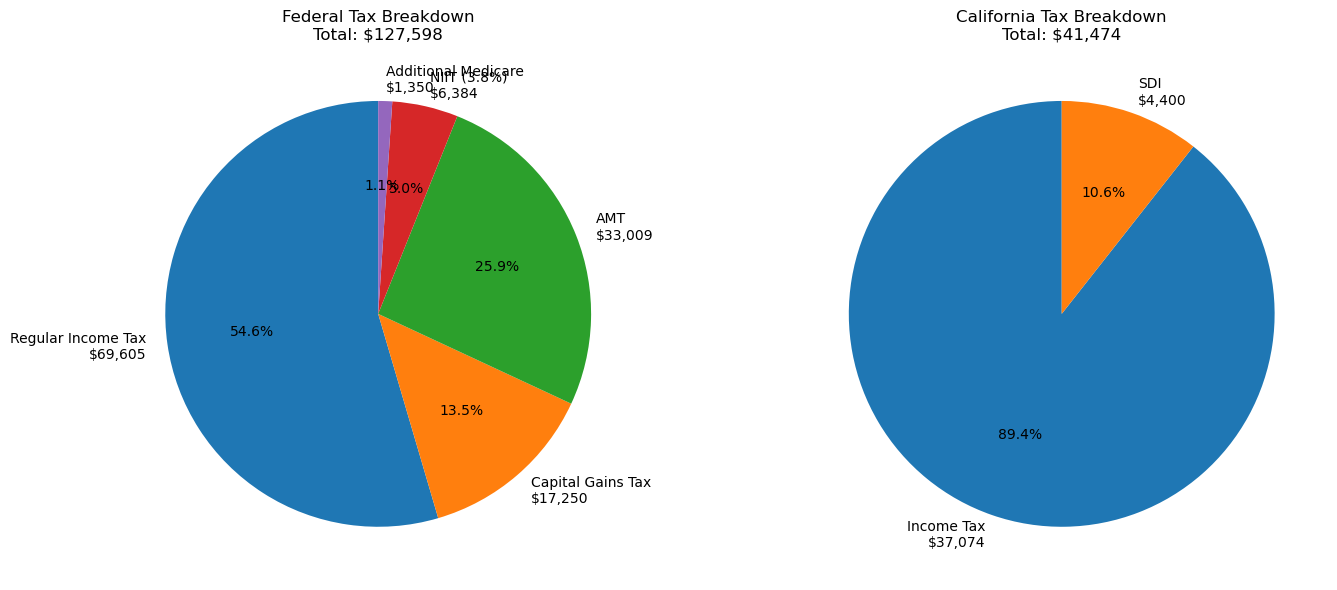

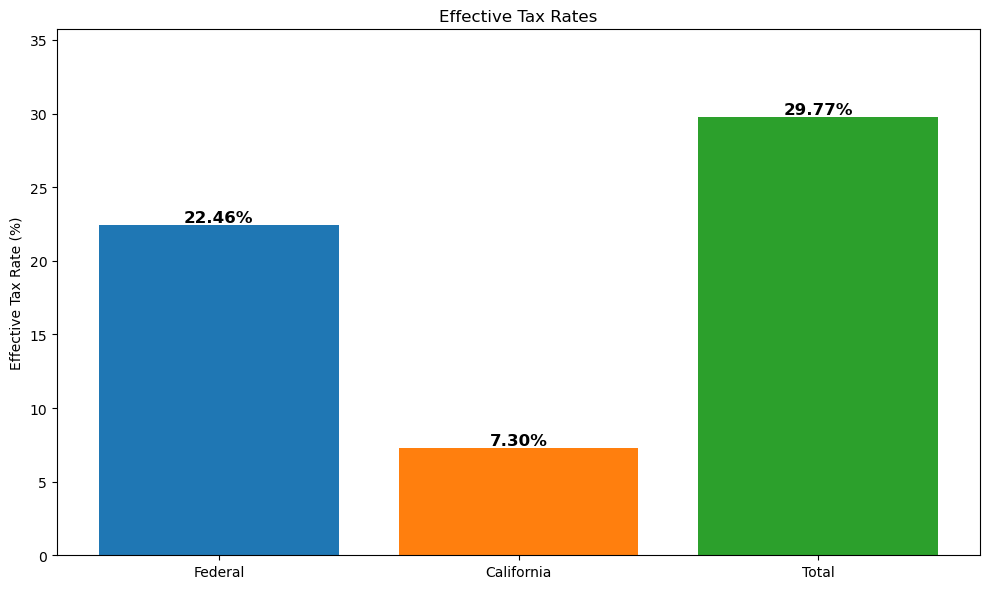

In [5]:
import matplotlib.pyplot as plt

# Using results from Example 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Federal tax breakdown
federal_components = [
    results.federal_income_tax,
    results.capital_gains_tax,
    results.amt_owed,
    results.niit_owed,
    results.additional_medicare_tax
]
federal_labels = [
    f'Regular Income Tax\n${results.federal_income_tax:,.0f}',
    f'Capital Gains Tax\n${results.capital_gains_tax:,.0f}',
    f'AMT\n${results.amt_owed:,.0f}',
    f'NIIT (3.8%)\n${results.niit_owed:,.0f}',
    f'Additional Medicare\n${results.additional_medicare_tax:,.0f}'
]

# Filter out zero values
federal_data = [(label, value) for label, value in zip(federal_labels, federal_components) if value > 0]
if federal_data:
    labels, values = zip(*federal_data)
    ax1.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
    ax1.set_title(f'Federal Tax Breakdown\nTotal: ${results.total_federal_tax:,.0f}')

# California tax breakdown
ca_components = [
    results.california_income_tax,
    results.california_mental_health_tax,
    results.california_sdi
]
ca_labels = [
    f'Income Tax\n${results.california_income_tax:,.0f}',
    f'Mental Health Tax\n${results.california_mental_health_tax:,.0f}',
    f'SDI\n${results.california_sdi:,.0f}'
]

# Filter out zero values
ca_data = [(label, value) for label, value in zip(ca_labels, ca_components) if value > 0]
if ca_data:
    labels, values = zip(*ca_data)
    ax2.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
    ax2.set_title(f'California Tax Breakdown\nTotal: ${results.total_california_tax:,.0f}')

plt.tight_layout()
plt.show()

# Overall effective rate visualization
fig, ax = plt.subplots(figsize=(10, 6))
categories = ['Federal', 'California', 'Total']
rates = [
    results.effective_federal_rate * 100,
    results.effective_california_rate * 100,
    results.effective_total_rate * 100
]

bars = ax.bar(categories, rates, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_ylabel('Effective Tax Rate (%)')
ax.set_title('Effective Tax Rates')
ax.set_ylim(0, max(rates) * 1.2)

# Add value labels on bars
for bar, rate in zip(bars, rates):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{rate:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Example 5: Custom Analysis Function

Create a reusable function for quick tax calculations:

In [6]:
def quick_tax_estimate(wages, capital_gains=0, filing_status='married_joint'):
    """
    Quick tax estimate with minimal inputs.
    
    Args:
        wages: W-2 wages
        capital_gains: Long-term capital gains (default 0)
        filing_status: 'single', 'married_joint', 'married_separate', or 'head_of_household'
    
    Returns:
        Dictionary with key tax metrics
    """
    # Convert filing status string to enum
    status_map = {
        'single': FilingStatus.SINGLE,
        'married_joint': FilingStatus.MARRIED_JOINT,
        'married_separate': FilingStatus.MARRIED_SEPARATE,
        'head_of_household': FilingStatus.HEAD_OF_HOUSEHOLD
    }
    
    taxpayer = TaxpayerInfo(
        filing_status=status_map[filing_status],
        age_primary=40
    )
    
    income = IncomeData(
        wages_w2=wages,
        long_term_capital_gains=capital_gains
    )
    
    itemized = ItemizedDeductions()
    
    calc = TaxCalculator2024(taxpayer, income, itemized)
    results = calc.calculate_all_taxes()
    
    return {
        'gross_income': results.gross_income,
        'taxable_income': results.taxable_income,
        'federal_tax': results.total_federal_tax,
        'california_tax': results.total_california_tax,
        'total_tax': results.total_tax_liability,
        'effective_rate': results.effective_total_rate * 100,
        'after_tax_income': results.gross_income - results.total_tax_liability
    }

# Test the function
estimate = quick_tax_estimate(wages=300000, capital_gains=50000, filing_status='married_joint')

print("Quick Tax Estimate:")
print(f"  Gross Income:       ${estimate['gross_income']:>12,.2f}")
print(f"  Federal Tax:        ${estimate['federal_tax']:>12,.2f}")
print(f"  California Tax:     ${estimate['california_tax']:>12,.2f}")
print(f"  Total Tax:          ${estimate['total_tax']:>12,.2f}")
print(f"  Effective Rate:     {estimate['effective_rate']:>12.2f}%")
print(f"  After-Tax Income:   ${estimate['after_tax_income']:>12,.2f}")

Quick Tax Estimate:
  Gross Income:       $  350,000.00
  Federal Tax:        $   60,927.00
  California Tax:     $   27,904.28
  Total Tax:          $   88,831.28
  Effective Rate:            25.38%
  After-Tax Income:   $  261,168.72


## Notes

- All calculations are based on 2024 tax year rates and brackets
- The calculator assumes above-the-line deductions (401k, IRA, HSA) have already been subtracted from wages
- For AMT calculations, consult with a tax professional for complex situations
- California treats all capital gains as ordinary income
- SALT deduction is capped at $10,000 for federal taxes